# Laboratorio 2: Regresión lineal multivariable

In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

import seaborn as sns

In [2]:
# Cargar datos
df = pd.read_csv('./train.csv')
print(df.columns)
y = df['critical_temp'].values
X_df = df.drop(columns=['critical_temp'])
X = X_df.values
m = y.size
print(X.shape[1])
print(m)
# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [3]:
def  featureNormalize(X):
    X_norm = X.copy()

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [4]:
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 4.         88.9444675  57.86269229 ...  1.08571429  0.4330127
   0.43705882]
 [ 5.         92.729214   58.51841614 ...  1.12857143  0.63245553
   0.46860627]
 [ 4.         88.9444675  57.88524186 ...  1.11428571  0.4330127
   0.44469664]
 ...
 [ 2.         99.66319    95.609104   ...  3.2         0.5
   0.4       ]
 [ 2.         99.66319    97.0956022  ...  2.21        0.5
   0.46249324]
 [ 3.         87.46833333 86.8585     ...  1.8         1.41421356
   1.5       ]]
Media calculada: [4.11522363e+00 8.75576309e+01 7.29883104e+01 7.12906270e+01
 5.85399156e+01 1.16560796e+00 1.06388353e+00 1.15601251e+02
 3.32252179e+01 4.43918933e+01 4.14480447e+01 7.69614748e+02
 8.70442317e+02 7.37474751e+02 8.32769649e+02 1.29917216e+00
 9.26725815e-01 5.72222612e+02 4.83517264e+02 2.15631279e+02
 2.24050033e+02 1.57983101e+02 1.34720039e+02 1.44448738e+02
 1.20989330e+02 1.26775588e+00 1.13113772e+00 1.39325025e+02
 5.13698849e+01 5.16012667e+01 5.23404649e+01 6.11146521e+03
 5.26718855e+03 3.4

In [5]:
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [6]:
print(X)

[[ 1.         -0.0800575   0.04673292 ... -0.40616628 -0.83837245
  -0.52006971]
 [ 1.          0.6147436   0.17426938 ... -0.36235194 -0.42686578
  -0.45082134]
 [ 1.         -0.0800575   0.04673292 ... -0.37695672 -0.83837245
  -0.50330427]
 ...
 [ 1.         -1.46965972  0.40792698 ...  1.75534096 -0.7001588
  -0.60141582]
 [ 1.         -1.46965972  0.40792698 ...  0.7432298  -0.7001588
  -0.46423977]
 [ 1.         -0.77485861 -0.0030091  ...  0.32407265  1.18612097
   1.81314381]]


In [7]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [8]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento
    theta = theta.copy()

    J_history = []
    for i in range(num_iters):
        err = np.dot(X, theta) - y
        theta = theta - (alpha / m) * np.dot(X.T, err)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [ 3.44212191e+01  1.32150974e+00  2.45502092e+00 -8.81717150e-01
  1.12185557e+00  4.54759217e-01 -3.26097933e+00  5.04499220e+00
  7.36418143e+00 -2.28910974e+00  2.19522125e+00 -4.55657265e+00
  9.12308507e-01 -2.16745585e-01  1.85158767e+00  7.46578276e-02
  5.62676967e-01  5.89107619e-01  3.93405402e+00  1.65100229e+00
 -3.43619514e+00 -2.47118700e+00  2.69424621e-01  5.33902609e+00
 -2.72315439e+00  9.63709187e-01 -1.82228454e-02  4.66444065e+00
  6.83304771e+00 -3.73685690e+00 -1.64244326e+00  3.65626611e+00
 -2.88810802e+00 -3.89940702e-01 -2.25883540e+00  7.31461567e-01
 -6.72602641e-01 -4.73260610e+00 -1.21454293e+00  3.10935366e+00
 -8.28107971e-02 -2.27260292e+00  2.95600288e+00  3.05113798e+00
 -2.20863393e-02 -5.44974676e+00 -3.53653184e+00 -6.80247640e+00
 -5.13603972e+00 -4.17197351e+00  5.06934090e+00 -1.96293478e+00
  1.23643391e+00  9.77854135e-02 -1.20081232e+00 -2.17456068e-01
  2.94023278e-01  5.54005850e+00 -2.1033

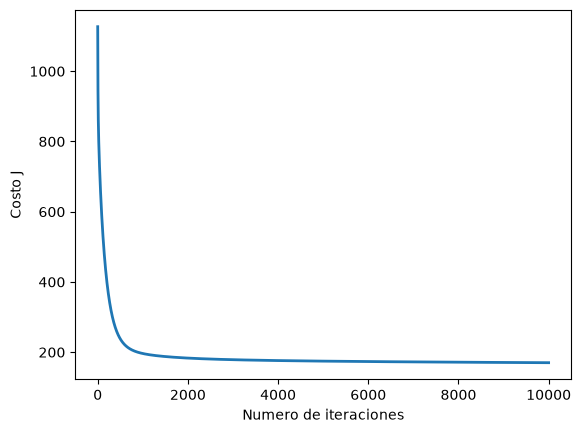

In [9]:
alpha = 0.003 # alpha = 0.001
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta_dg, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta_dg)))

ejemplo = X_df.iloc[187].values
ejemplo_dg = (ejemplo - mu) / sigma
X_array = np.insert(ejemplo_dg, 0, 1)
temp_pred = np.dot(X_array, theta_dg)
y_pred_n = np.dot(X, theta_dg)

print(f'Valor de critical_temp: {y[187]}')
print(f'Temperatura crítica predicha por descenso por el gradiente: {temp_pred:.2f}')



In [10]:
# Cargar datos
df = pd.read_csv('./train.csv')
X_df = df.drop(columns=['critical_temp'])
X = X_df.values
y = df['critical_temp'].values
m = y.size
print(m)
print(X.shape[1])
X = np.concatenate([np.ones((m, 1)), X], axis=1)

21263
81


In [11]:
def normalEqn(X, y):
    #theta = np.zeros(X.shape[1])

    #theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)
    theta = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

In [12]:
# Calcula los parametros con la ecuación de la normal
theta_n = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_n)));

ejemplo_n = np.insert(X_df.iloc[187].values, 0, 1)
temp_pred_n = np.dot(ejemplo_n, theta_n)

print(f'Temperatura crítica predicha por Ecuación de la Normal: {temp_pred_n:.2f}')

Theta calculado a partir de la ecuación de la normal: [-2.08065781e+01 -3.49645389e+00  8.48041667e-01 -9.04069942e-01
 -5.10198861e-01  6.46808298e-01 -3.59605940e+01  4.55452131e+00
  2.14180413e-01  2.59837154e-02 -5.60802142e-01  9.04805513e-02
  1.60105025e-01 -1.78703328e-01 -1.52374224e-01  1.98418084e-01
 -1.18698810e+02  4.41439360e+01  6.82124153e-02  2.14655894e-02
 -1.98553723e-01 -2.32311478e-02 -5.35097605e-01  3.25682882e+00
  2.00871994e-01 -2.86245468e+00  7.93162801e+01  4.48242255e+01
  1.95202780e-01 -9.14819030e-02 -3.55833180e-01 -3.31789660e-01
 -4.75247509e-03 -1.66351612e-04  1.16678992e-03  2.32793112e-03
  1.60731486e+01 -1.97887747e+01 -1.58173079e-03 -5.20168921e-05
  6.08763786e-03 -1.58375273e-03 -1.09619284e-01  5.17202763e-01
  1.80116695e-01 -5.73226826e-01  4.48705939e+00 -2.12194113e+01
 -3.67686380e-01 -1.38922460e-01  1.24323831e+00 -5.42843865e-01
  1.73292845e+00 -1.94278094e+00 -1.55836320e+00  1.62047221e+00
 -1.94622621e+01  2.54396549e+01 -3.

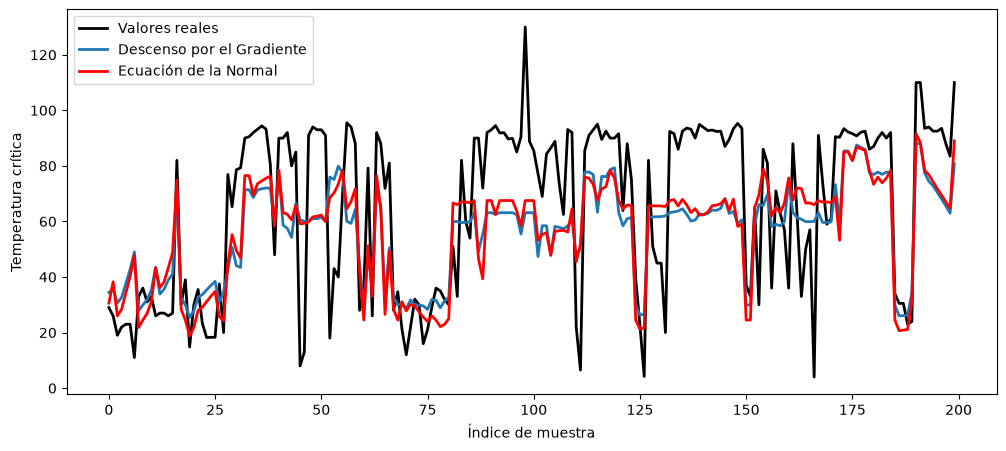

In [13]:
X_dg = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
y_pred_dg = np.dot(X_dg, theta_dg)
X_norm_eq = np.concatenate([np.ones((m, 1)), X_df.values], axis=1)
y_pred_n = np.dot(X_norm_eq, theta_n)
pyplot.figure(figsize=(12, 5)) 
pyplot.plot(y[:200], label='Valores reales', color='black', lw=2)
pyplot.plot(y_pred_dg[:200], label='Descenso por el Gradiente', lw=2)
pyplot.plot(y_pred_n[:200], label='Ecuación de la Normal', color='red', lw=2)
pyplot.xlabel('Índice de muestra')
pyplot.ylabel('Temperatura crítica')
pyplot.legend()